In [20]:
!pip -q install dune-client
import pandas as pd
from google.colab import userdata
from dune_client.client import DuneClient

dune = DuneClient(DUNE_KEY)

QUERY_ID = 6694165
res = dune.get_latest_result(QUERY_ID)

df = pd.DataFrame(res.result.rows)
df.head()

,dai_balance,dai_flow,dai_p,dt,dt_ordering,total_tvl,total_tvl_for_counter,usdc_balance,usdc_flow,usdc_p,usdc_p_for_counter,usdt_balance,usdt_flow,usdt_p,usdt_p_for_counter
0,1.631679e+08,0.300000,0.371669,2023-03-31 23:00:00,1,4.390136e+08,439.013639,1.798454e+08,-8.004156e+05,0.409658,40.965794,9.600034e+07,6.188702e+05,0.218673,21.867280
1,1.631679e+08,-51129.159258,0.371516,2023-03-31 22:00:00,2,4.391952e+08,439.195184,1.806458e+08,8.145945e+06,0.411311,41.131106,9.538147e+07,-8.152090e+06,0.217173,21.717331
2,1.632190e+08,-42927.333904,0.371584,2023-03-31 21:00:00,3,4.392525e+08,439.252459,1.724999e+08,-2.705150e+05,0.392712,39.271241,1.035336e+08,2.938631e+05,0.235704,23.570400
3,1.632619e+08,-4081.323458,0.371665,2023-03-31 20:00:00,4,4.392720e+08,439.272038,1.727704e+08,-2.998123e+06,0.393311,39.331073,1.032397e+08,2.978210e+06,0.235025,23.502452
4,1.632660e+08,-541970.690054,0.371654,2023-03-31 19:00:00,5,4.392960e+08,439.296033,1.757685e+08,-1.469202e+06,0.400114,40.011409,1.002615e+08,2.016571e+06,0.228232,22.823218


cols: ['dai_balance', 'dai_flow', 'dai_p', 'dt', 'dt_ordering', 'total_tvl', 'total_tvl_for_counter', 'usdc_balance', 'usdc_flow', 'usdc_p', 'usdc_p_for_counter', 'usdt_balance', 'usdt_flow', 'usdt_p', 'usdt_p_for_counter']


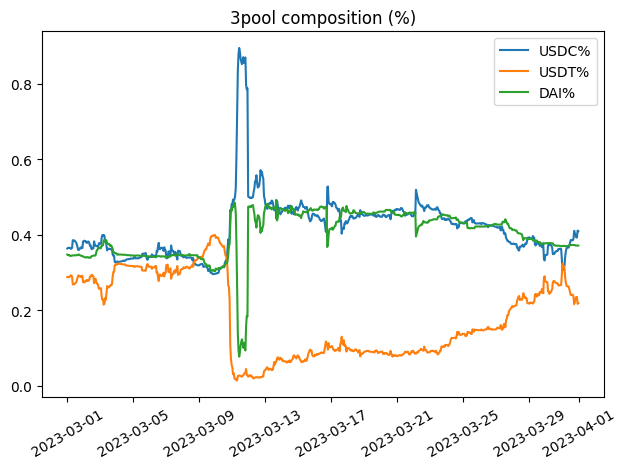

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

QUERY_ID = 6694165
res = dune.get_latest_result(QUERY_ID)
df = pd.DataFrame(res.result.rows)

# normalize timestamp column name
if "dt" not in df.columns:
    for c in ["date", "block_time", "timestamp", "time"]:
        if c in df.columns:
            df = df.rename(columns={c: "dt"})
            break

print("cols:", df.columns.tolist())

df["dt"] = pd.to_datetime(df["dt"], utc=True, errors="coerce")
df = df.dropna(subset=["dt"]).sort_values("dt")

need = {"usdc_p","usdt_p","dai_p"}
if not need.issubset(df.columns):
    print("This result does NOT include composition % columns:", need - set(df.columns))
    print("You are probably on the Token Flows result. Use the '3pool Composition' tab's query id instead.")
else:
  #1. plot
  plt.figure()
  plt.plot(df["dt"], df["usdc_p"], label="USDC%")
  plt.plot(df["dt"], df["usdt_p"], label="USDT%")
  plt.plot(df["dt"], df["dai_p"],  label="DAI%")
  plt.legend()
  plt.xticks(rotation=30)
  plt.title("3pool composition (%)")
  plt.tight_layout()
  plt.show()

This chart shows the inventory composition of Curve’s 3pool (USDC/USDT/DAI) over March 2023 using Dune on-chain data. The key event window occurs around Mar 10–12, when USDC briefly depegged. During this period, the pool becomes highly one-sided: USDC’s share spikes to ~85–90% while USDT liquidity is nearly depleted, consistent with a bank-run style flow where traders swap USDC into the pool and drain the “good” assets (USDT/DAI). After the peak stress, the composition does not immediately revert to a balanced ~1/3–1/3–1/3 state; instead, it normalizes gradually over the following days/weeks, indicating that rebalancing requires sustained arbitrage and liquidity adjustments rather than instant mean reversion.


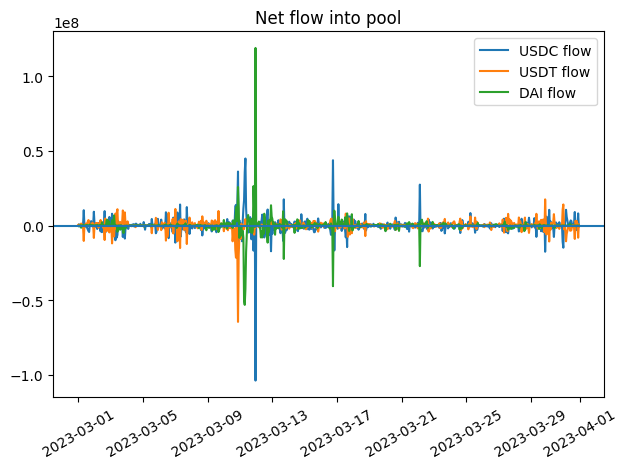

In [23]:
#2. Netflow
plt.figure()
plt.plot(df["dt"], df["usdc_flow"], label="USDC flow")
plt.plot(df["dt"], df["usdt_flow"], label="USDT flow")
plt.plot(df["dt"], df["dai_flow"],  label="DAI flow")
plt.axhline(0)
plt.legend()
plt.xticks(rotation=30)
plt.title("Net flow into pool")
plt.tight_layout()
plt.show()

This plot shows hourly net inventory changes of the 3pool (validated to match balance differences). Values above zero indicate net inflows into the pool (inventory increases), while negative values indicate net outflows (inventory is drained). The most salient feature occurs around Mar 9–12, coinciding with the USDC depeg episode: USDT experiences large negative spikes, consistent with rapid drainage of the “good” asset as traders rotated out of USDC into USDT/DAI. In the days following the peak stress, flow magnitudes compress toward zero with sporadic spikes, suggesting gradual rebalancing driven by arbitrage and liquidity adjustments rather than an immediate return to equilibrium.

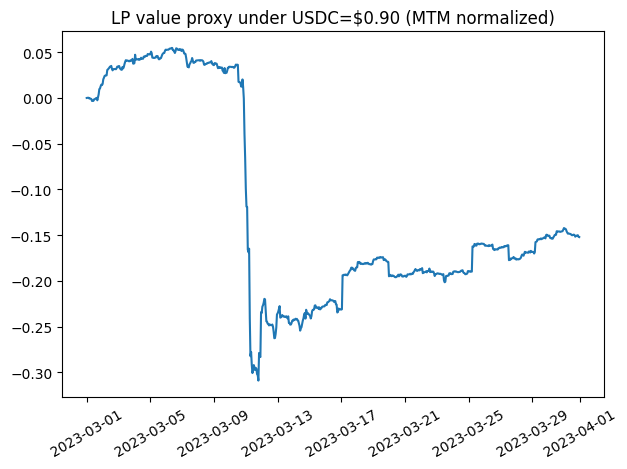

In [5]:
#3. LP proxy
usdc_price = 0.90
df["pool_mtm"] = df["usdc_balance"]*usdc_price + df["usdt_balance"]*1.0 + df["dai_balance"]*1.0
df["pool_mtm_norm"] = df["pool_mtm"] / df["pool_mtm"].iloc[0] - 1

plt.figure()
plt.plot(df["dt"], df["pool_mtm_norm"])
plt.xticks(rotation=30)
plt.title("LP value proxy under USDC=$0.90 (MTM normalized)")
plt.tight_layout()
plt.show()

Under a static stress assumption of USDC = $0.90, the pool’s mark-to-market (MTM) value proxy experiences a sharp drawdown around Mar 9–11 (depeg window), reaching roughly ~30% at the trough, and then only partially recovers, remaining negative through month-end.

The following performs a post-mortem analysis of Curve 3pool during the March 2023 USDC depeg. Using Dune on-chain time series (hourly balances, net flows, and composition), (i) quantify pool imbalance via an L1 distance from equal weights, (ii) visualize how the pool becomes one-sided during the stress window, (iii) estimate LP downside exposure using a static mark-to-market revaluation scenario (e.g., USDC=$0.88), and (iv) interpret panic vs rebalancing behavior using net flow dynamics and a balance-flow consistency check.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df["dt"] = pd.to_datetime(df["dt"], utc=True, errors="coerce")
df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)

# event window
t0 = pd.Timestamp("2023-03-10", tz="UTC")
t1 = pd.Timestamp("2023-03-14", tz="UTC")
w = df[(df["dt"]>=t0) & (df["dt"]<t1)].copy()

print(w["dt"].min(), w["dt"].max(), w.shape)
w.head()

2023-03-10 00:00:00+00:00 2023-03-13 23:00:00+00:00 (96, 15)


,dai_balance,dai_flow,dai_p,dt,dt_ordering,total_tvl,total_tvl_for_counter,usdc_balance,usdc_flow,usdc_p,usdc_p_for_counter,usdt_balance,usdt_flow,usdt_p,usdt_p_for_counter
216,1.645499e+08,3.699025e+06,0.310914,2023-03-10 00:00:00+00:00,24,5.292451e+08,529.245084,1.571856e+08,108995.507780,0.297000,29.699959,2.075097e+08,-3.802978e+06,0.392086,39.208612
217,1.634268e+08,-1.123041e+06,0.308782,2023-03-10 01:00:00+00:00,23,5.292634e+08,529.263351,1.579833e+08,797682.908402,0.298497,29.849650,2.078533e+08,3.436254e+05,0.392722,39.272184
218,1.634381e+08,1.130132e+04,0.308802,2023-03-10 02:00:00+00:00,22,5.292653e+08,529.265309,1.578993e+08,-83923.429220,0.298337,29.833683,2.079279e+08,7.458009e+04,0.392861,39.286130
219,1.634101e+08,-2.796838e+04,0.308822,2023-03-10 03:00:00+00:00,21,5.291394e+08,529.139428,1.580663e+08,166955.890852,0.298723,29.872333,2.076630e+08,-2.648679e+05,0.392454,39.245420
220,1.653082e+08,1.898094e+06,0.312297,2023-03-10 04:00:00+00:00,20,5.293297e+08,529.329695,1.586091e+08,542788.927114,0.299641,29.964138,2.054124e+08,-2.250617e+06,0.388061,38.806131


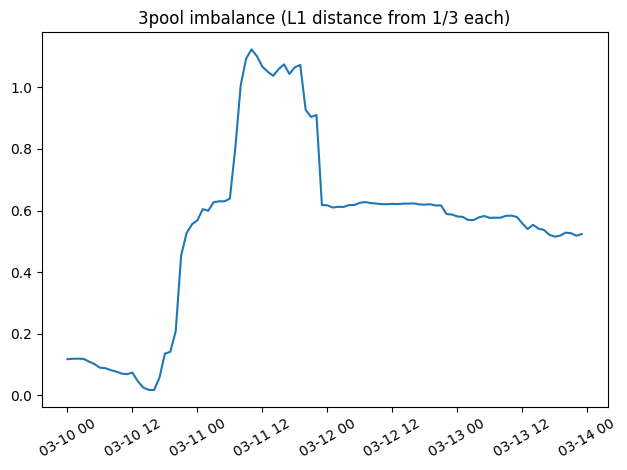

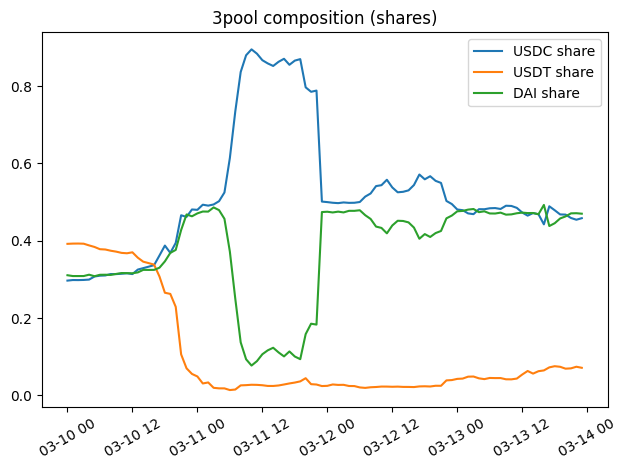

In [25]:
w["total_bal"] = w["usdc_balance"] + w["usdt_balance"] + w["dai_balance"]
w["share_usdc"] = w["usdc_balance"]/w["total_bal"]
w["share_usdt"] = w["usdt_balance"]/w["total_bal"]
w["share_dai"]  = w["dai_balance"]/w["total_bal"]

# imbalance metric: L1 distance from 1/3 each
w["imbalance_l1"] = (w["share_usdc"]-1/3).abs() + (w["share_usdt"]-1/3).abs() + (w["share_dai"]-1/3).abs()


plt.figure()
plt.plot(w["dt"], w["imbalance_l1"])
plt.xticks(rotation=30)
plt.title("3pool imbalance (L1 distance from 1/3 each)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(w["dt"], w["share_usdc"], label="USDC share")
plt.plot(w["dt"], w["share_usdt"], label="USDT share")
plt.plot(w["dt"], w["share_dai"],  label="DAI share")
plt.legend()
plt.xticks(rotation=30)
plt.title("3pool composition (shares)")
plt.tight_layout()
plt.show()

During the March 2023 USDC depeg window, the imbalance metric spikes sharply (peaking around ~1.1), consistent with a bank-run regime in which traders swap USDC into the pool and drain the “good” assets (USDT/DAI). The composition plot confirms this mechanism: USDC share briefly rises to ~85–90% while USDT becomes nearly depleted. After the peak stress, both imbalance and composition partially normalize but do not immediately return to equilibrium, which means rebalancing is gradual and driven by subsequent arbitrage and liquidity adjustments.

In [26]:
peak_i = w["share_usdc"].idxmax()
w.loc[[peak_i-1, peak_i, peak_i+1], ["dt","usdc_balance","usdt_balance","dai_balance","share_usdc","share_usdt","share_dai"]]

,dt,usdc_balance,usdt_balance,dai_balance,share_usdc,share_usdt,share_dai
249,2023-03-11 09:00:00+00:00,3.392885e+08,1.027224e+07,3.606034e+07,0.879849,0.026638,0.093512
250,2023-03-11 10:00:00+00:00,3.413041e+08,1.053093e+07,2.947678e+07,0.895079,0.027618,0.077304
251,2023-03-11 11:00:00+00:00,3.383319e+08,1.047141e+07,3.395049e+07,0.883941,0.027358,0.088701


Around 2023-03-11 10:00 UTC, the Curve 3pool became extremely one-sided: USDC accounted for ~89.5% of pool inventory, while USDT dropped to ~2.76% and DAI to ~7.73%. This snapshot is consistent with a bank-run dynamic during the USDC depeg, where traders swapped USDC into the pool and drained the “good” assets (USDT/DAI), effectively turning the pool into a USDC warehouse.


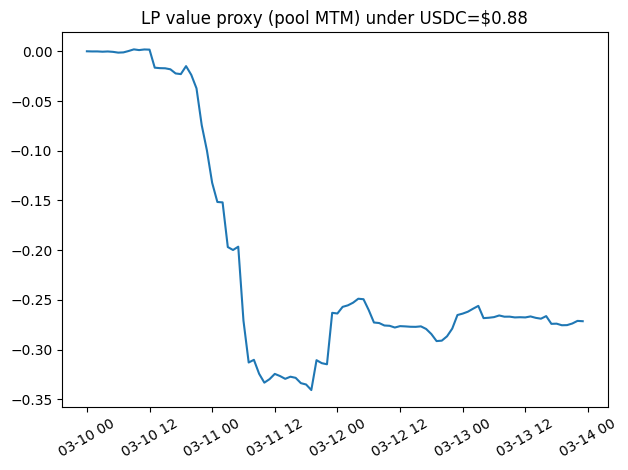

Worst MTM drawdown: -0.34058478146848603
Peak imbalance: 1.1234908406400765


In [27]:
#static shock
USDC_SHOCK = 0.88

w["pool_mtm_usd"] = w["usdt_balance"]*1.0 + w["dai_balance"]*1.0 + w["usdc_balance"]*USDC_SHOCK
w["pool_mtm_norm"] = w["pool_mtm_usd"]/w["pool_mtm_usd"].iloc[0] - 1

plt.figure()
plt.plot(w["dt"], w["pool_mtm_norm"])
plt.xticks(rotation=30)
plt.title(f"LP value proxy (pool MTM) under USDC=${USDC_SHOCK}")
plt.tight_layout()
plt.show()

print("Worst MTM drawdown:", float(w["pool_mtm_norm"].min()))
print("Peak imbalance:", float(w["imbalance_l1"].max()))

The MTM proxy exhibits a sharp drawdown during the peak stress period, reaching a worst drawdown of ~34%, coinciding with extreme pool imbalance (peak L1 imbalance ~1.12) when the pool becomes heavily skewed toward USDC. This is a stress revaluation proxy (static repricing), not realized LP token PnL (it does not use virtual_price or a time-varying USDC price path).

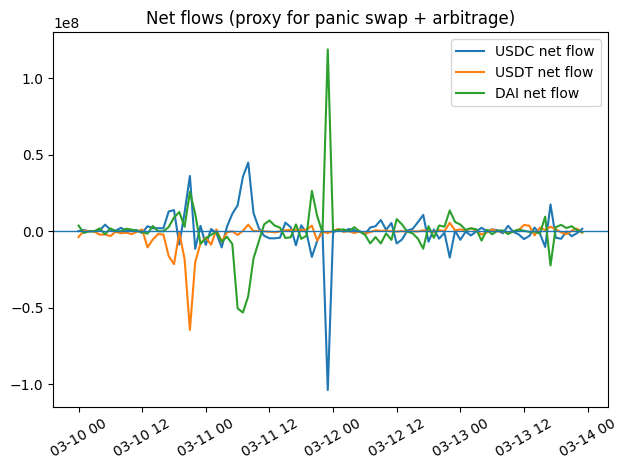

imbalance_l1    1.000000
usdc_flow      -0.021557
usdt_flow       0.219903
dai_flow       -0.102604
Name: imbalance_l1, dtype: float64


In [10]:
plt.figure()
plt.plot(w["dt"], w["usdc_flow"], label="USDC net flow")
plt.plot(w["dt"], w["usdt_flow"], label="USDT net flow")
plt.plot(w["dt"], w["dai_flow"],  label="DAI net flow")
plt.axhline(0, linewidth=1)
plt.legend()
plt.xticks(rotation=30)
plt.title("Net flows (proxy for panic swap + arbitrage)")
plt.tight_layout()
plt.show()

# quick correlation: is imbalance rising when USDC inflow is large?
tmp = w[["imbalance_l1","usdc_flow","usdt_flow","dai_flow"]].dropna()
print(tmp.corr(numeric_only=True)["imbalance_l1"])

In [11]:
w2 = w.sort_values("dt").copy()

for coin in ["usdc","usdt","dai"]:
    d_bal = w2[f"{coin}_balance"].diff()
    corr = np.corrcoef(d_bal.dropna(), w2[f"{coin}_flow"].iloc[1:].values)[0,1]
    print(coin, "corr(diff(balance), flow) =", corr)

usdc corr(diff(balance), flow) = 1.0
usdt corr(diff(balance), flow) = 0.9999999999999999
dai corr(diff(balance), flow) = 1.0


## Simlations

In [30]:
def mtm_drawdown(df_window, usdc_px):
    v = df_window["usdt_balance"] + df_window["dai_balance"] + df_window["usdc_balance"]*usdc_px
    return float(v.min()/v.iloc[0] - 1)

#stress revaluation proxy
for px in [0.95, 0.90, 0.88]:
    print(px, mtm_drawdown(w, px))

0.95 -0.31061638541185044
0.9 -0.331891339160825
0.88 -0.34058478146848603


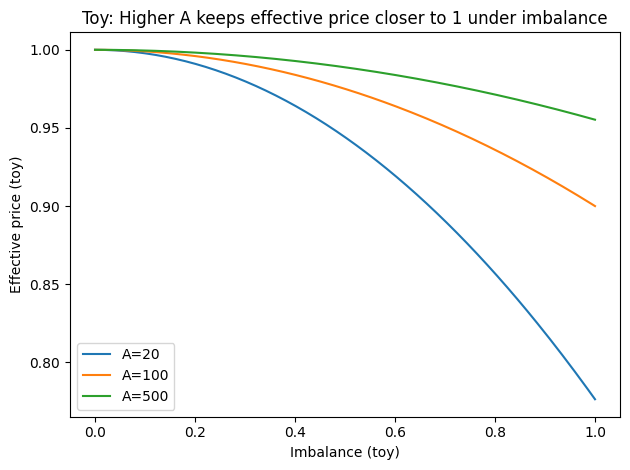

In [31]:
imb = np.linspace(0, 1.0, 200)
A_list = [20, 100, 500]

plt.figure()
for A in A_list:
    penalty = (imb**2) / np.sqrt(A)     # just toy simulation: higher A -> slower degradation
    eff_price = 1.0 - penalty
    plt.plot(imb, eff_price, label=f"A={A}")

plt.title("Toy: Higher A keeps effective price closer to 1 under imbalance")
plt.xlabel("Imbalance (toy)")
plt.ylabel("Effective price (toy)")
plt.legend()
plt.tight_layout()
plt.show()

A (Amplification coefficient) in Curve StableSwap controls how “flat” the pricing curve is around the 1:1 peg. A higher A keeps swaps closer to 1:1 with lower slippage under normal conditions, while a lower A introduces slippage earlier as the pool becomes imbalanced. In depeg/bank-run regimes, A materially affects how costly it is to drain the scarce “good” asset from the pool.

The above define a simulated p_eff = 1-imbalance^2/sqrt(A)

In this toy mapping, imbalance increases the penalty (reducing the effective price), while larger A dampens the penalty, producing flatter curves. This is not the exact Curve invariant pricing function and is included only to communicate the qualitative direction of A’s effect under imbalance; the mechanism-level results should rely on the StableSwap-based slippage/execution simulations.

## Simulation: StableSwap Invariant


This code implements a StableSwap-style invariant solver for a 3-asset stable pool. It first computes the pool invariant D from precision-normalized balances xp and amplification A, then solves for the post-swap output balance y given an input amount dx, and finally derives the swap output dy = x_j-y_new (optionally applying fees). Balances are scaled to a common 1e18 precision (USDC/USDT 6 decimals → ×1e12; DAI already 18 decimals) to ensure consistent arithmetic.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- StableSwap math (3 coins) ----------
N_COINS = 3

def get_D(xp, A):
    """
    Solve StableSwap invariant D for N=3.
    xp: array-like, scaled balances (same precision)
    A: amplification coefficient (already scaled as A, not A*n^n)
    """
    xp = np.array(xp, dtype=np.float64)
    S = xp.sum()
    if S == 0:
        return 0.0

    D = S
    Ann = A * (N_COINS ** N_COINS)
    for _ in range(255):
        D_P = D
        for x in xp:
            D_P = D_P * D / (x * N_COINS)
        D_prev = D
        # Newton step
        D = (Ann * S + D_P * N_COINS) * D / ((Ann - 1) * D + (N_COINS + 1) * D_P)
        if abs(D - D_prev) <= 1e-9 * D:
            break
    return float(D)

def get_y(i, j, x_i, xp, A):
    """
    Given xp balances, set coin i to x_i (after adding dx),
    solve new y for coin j.
    """
    xp = np.array(xp, dtype=np.float64)
    D = get_D(xp, A)
    Ann = A * N_COINS

    c = D
    S_ = 0.0
    for k in range(N_COINS):
        if k == i:
            x = x_i
        elif k == j:
            continue
        else:
            x = xp[k]
        S_ += x
        c = c * D / (x * N_COINS)

    c = c * D / (Ann * N_COINS)
    b = S_ + D / Ann

    y = D
    for _ in range(255):
        y_prev = y
        y = (y*y + c) / (2*y + b - D)
        if abs(y - y_prev) <= 1e-9 * y:
            break
    return float(y)

def swap_out(i, j, dx, xp, A, fee=0.0):
    """
    Compute dy out for swap i -> j with dx in (all in xp precision).
    fee is optional; set 0 for pure invariant sensitivity.
    """
    x_i = xp[i] + dx
    y_new = get_y(i, j, x_i, xp, A)
    dy = xp[j] - y_new
    dy_fee = dy * (1 - fee)
    return float(dy_fee)

# decimals: USDC 6, USDT 6, DAI 18
def to_xp(usdc, usdt, dai):
    # scale to 1e18 precision (like Curve's "xp" idea)
    xp_usdc = usdc * 1e12   # 1e6 -> 1e18
    xp_usdt = usdt * 1e12
    xp_dai  = dai * 1e0     # already 1e18
    return np.array([xp_usdc, xp_usdt, xp_dai], dtype=np.float64)

def from_xp_amount(xp_amt, decimals_target=6):
    # convert xp (1e18) back to token units
    if decimals_target == 6:
        return xp_amt / 1e12
    if decimals_target == 18:
        return xp_amt
    raise ValueError("unsupported decimals")

In [33]:
peak_idx = w["imbalance_l1"].idxmax()
row = w.loc[peak_idx]

x_usdc = float(row["usdc_balance"])
x_usdt = float(row["usdt_balance"])
x_dai  = float(row["dai_balance"])
t_peak = row["dt"]

print("peak dt:", t_peak)
print("balances:", x_usdc, x_usdt, x_dai)

xp0 = to_xp(x_usdc, x_usdt, x_dai)

# simulate USDC -> USDT swaps for different A
A_list = [20, 100, 500]

# trade sizes in USDC token units (not xp)
trade_sizes = np.array([1e4, 2e4, 5e4, 1e5, 2e5, 5e5, 1e6])

rows_out = []
for A in A_list:
    for dx_usdc in trade_sizes:
        dx_xp = dx_usdc * 1e12
        dy_xp = swap_out(i=0, j=1, dx=dx_xp, xp=xp0, A=A, fee=0.0)
        dy_usdt = from_xp_amount(dy_xp, decimals_target=6)

        eff_price = dy_usdt / dx_usdc
        slippage_bps = (1 - eff_price) * 1e4

        rows_out.append({
            "A": A,
            "dx_usdc": dx_usdc,
            "dy_usdt": dy_usdt,
            "eff_price": eff_price,
            "slippage_bps": slippage_bps
        })

out = pd.DataFrame(rows_out)
out

peak dt: 2023-03-11 10:00:00+00:00
balances: 341304067.94656014 10530928.827653207 29476777.808175657


,A,dx_usdc,dy_usdt,eff_price,slippage_bps
0,20,10000.0,-6.872180e+07,-6872.179539,6.873180e+07
1,20,20000.0,-6.871825e+07,-3435.912700,3.436913e+07
2,20,50000.0,-6.870763e+07,-1374.152621,1.375153e+07
3,20,100000.0,-6.868993e+07,-686.899303,6.878993e+06
4,20,200000.0,-6.865454e+07,-343.272721,3.442727e+06
5,20,500000.0,-6.854851e+07,-137.097019,1.380970e+06
6,20,1000000.0,-6.837220e+07,-68.372196,6.937220e+05
7,100,10000.0,-6.870995e+07,-6870.995455,6.871995e+07
8,100,20000.0,-6.870641e+07,-3435.320626,3.436321e+07
9,100,50000.0,-6.869579e+07,-1373.915753,1.374916e+07


The above negative dy are economically impossible and might indicates some numarical instability, so we rely on the more numerically stable USDC/USDT 2-coin silce implementation first.

## 2-coin analysis

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_D_2(xp, A):
    # N=2 stableswap
    x0, x1 = xp
    S = x0 + x1
    if S == 0: return 0.0
    D = S
    Ann = A * 2
    for _ in range(255):
        D_prev = D
        D_P = D*D/(x0*2) * D/(x1*2)
        D = (Ann*S + 2*D_P)*D / ((Ann-1)*D + 3*D_P)
        if abs(D - D_prev) <= 1e-9 * D:
            break
    return float(D)

def get_y_2(i, j, x_i, xp, A):
    # solve y for coin j given coin i set to x_i
    x0, x1 = xp
    D = get_D_2(xp, A)
    Ann = A * 2
    if i == 0:
        x = x_i
        y0 = x1
    else:
        x = x_i
        y0 = x0

    c = D*D / (x*2)
    c = c * D / (Ann*2)
    b = x + D/Ann

    y = D
    for _ in range(255):
        y_prev = y
        y = (y*y + c) / (2*y + b - D)
        if abs(y - y_prev) <= 1e-9 * y:
            break
    return float(y)

def swap_out_2(dx, xp, A, fee=0.0):
    # swap coin0 -> coin1 (USDC -> USDT)
    y_new = get_y_2(0, 1, xp[0] + dx, xp, A)
    dy = xp[1] - y_new
    dy = dy * (1 - fee)
    return float(dy)


peak_idx = w["imbalance_l1"].idxmax()
row = w.loc[peak_idx]

x_usdc = float(row["usdc_balance"])
x_usdt = float(row["usdt_balance"])
t_peak = row["dt"]

# scale to 1e18 precision
xp2 = np.array([x_usdc*1e12, x_usdt*1e12], dtype=np.float64)

print("peak dt:", t_peak)
print("USDT available:", x_usdt)

A_list = [20, 100, 500]
trade_sizes = np.array([1e4, 5e4, 1e5, 2e5, 5e5, 1e6, 2e6, 3e6])

rows=[]
for A in A_list:
    for dx_usdc in trade_sizes:
        dx = dx_usdc*1e12
        dy_xp = swap_out_2(dx, xp2, A, fee=0.0)
        dy_usdt = dy_xp/1e12
        eff_price = dy_usdt/dx_usdc
        slippage_bps = (1-eff_price)*1e4
        rows.append({"A":A,"dx_usdc":dx_usdc,"dy_usdt":dy_usdt,"eff_price":eff_price,"slippage_bps":slippage_bps})

out2 = pd.DataFrame(rows)
out2

peak dt: 2023-03-11 10:00:00+00:00
USDT available: 10530928.827653207


,A,dx_usdc,dy_usdt,eff_price,slippage_bps
0,20,10000.0,1.965552e+03,0.196555,8034.447869
1,20,50000.0,9.822485e+03,0.196450,8035.503061
2,20,100000.0,1.963179e+04,0.196318,8036.820873
3,20,200000.0,3.921095e+04,0.196055,8039.452569
4,20,500000.0,9.763418e+04,0.195268,8047.316323
5,20,1000000.0,1.939681e+05,0.193968,8060.318661
6,20,2000000.0,3.828125e+05,0.191406,8085.937655
7,20,3000000.0,5.666850e+05,0.188895,8111.049924
8,100,10000.0,4.527403e+03,0.452740,5472.596915
9,100,50000.0,2.261643e+04,0.452329,5476.714289


In [35]:
# dy must be positive and less than available USDT
check = out2[out2["dx_usdc"]==1e6].sort_values("A")
print(check[["A","dy_usdt","eff_price","slippage_bps"]])

assert (out2["dy_usdt"] > 0).all(), "dy should be positive"
assert (out2["dy_usdt"] < x_usdt + 1e-6).all(), "dy cannot exceed available USDT"

      A        dy_usdt  eff_price  slippage_bps
5    20  193968.133870   0.193968   8060.318661
13  100  442591.867601   0.442592   5574.081324
21  500  774258.342779   0.774258   2257.416572


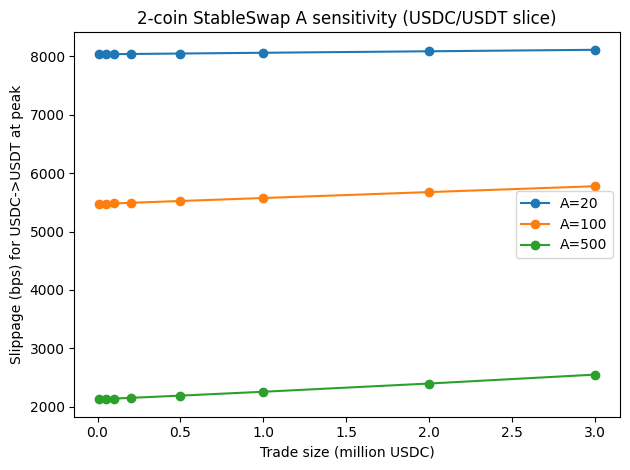

In [36]:
plt.figure()
for A in A_list:
    sub = out2[out2["A"]==A].sort_values("dx_usdc")
    plt.plot(sub["dx_usdc"]/1e6, sub["slippage_bps"], marker="o", label=f"A={A}")
plt.xlabel("Trade size (million USDC)")
plt.ylabel("Slippage (bps) for USDC->USDT at peak")
plt.title("2-coin StableSwap A sensitivity (USDC/USDT slice)")
plt.legend()
plt.tight_layout()
plt.show()

The higher A materially reduces slippage under extreme imbalance (e.g., for 1M USDC, slippage drops from ~8000 bps at A=20 to ~2200 bps at A=500), implying that larger A lowers the cost of draining scarce “good” liquidity during depeg/bank-run regimes.